
# TP — Classification de feuilles (lisse vs dentée) — 

`


In [1]:
import os, random, math, zipfile, shutil, glob
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve)

import matplotlib.pyplot as plt

# ---- Reproductibilité & device
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Chemins Kaggle
INPUT = Path("/kaggle/input")
WORK  = Path("/kaggle/working")
RAW_ROOTS = [
    INPUT / "feuilles-plantes",           
    INPUT / "feuilles_plantes",           
    INPUT                                  
]
WORK_DATA = WORK / "data" / "feuilles"   
WORK_DATA.mkdir(parents=True, exist_ok=True)

def find_zip_or_folders():
    zip_cands = list(INPUT.rglob("feuilles_plantes.zip"))
    if zip_cands:
        return ("zip", zip_cands[0])
    for root in RAW_ROOTS:
        d = root / "feuilles_plantes"
        if d.exists() and d.is_dir():
            return ("dir", d)
    for root in RAW_ROOTS:
        dente = list(root.rglob("dente"))
        lisse = list(root.rglob("lisse"))
        if dente and lisse:
            return ("dir-multi", root)
    return (None, None)

kind, src = find_zip_or_folders()
print("Input kind:", kind, "| src:", src)

# ---- Décompression / Copie en structure claire data/feuilles/{dentee,lisse}
def prepare_dataset(kind, src, out_root: Path):
    mapping = {"dente":"dentee", "lisse":"lisse"}
    moved = {"dentee":0, "lisse":0}

    if kind == "zip" and src is not None:
        with zipfile.ZipFile(src, "r") as z:
            z.extractall(WORK)
        base = WORK / "feuilles_plantes"
    elif kind == "dir" and src is not None:
        base = src
    elif kind == "dir-multi" and src is not None:
        base = src
    else:
        raise RuntimeError("Jeu de données introuvable. Ajoute ton dataset au notebook Kaggle.")

    # Copie les images dans out_root
    out_root.mkdir(parents=True, exist_ok=True)
    # Essaye d’abord le cas standard: .../feuilles_plantes/dente et .../feuilles_plantes/lisse
    candidates = [(base/"dente"), (base/"lisse")]
    if not all([c.exists() for c in candidates]):
        # sinon cherche globalement
        dente_dirs = list(base.rglob("dente"))
        lisse_dirs = list(base.rglob("lisse"))
        if not (dente_dirs and lisse_dirs):
            raise RuntimeError("Impossible de trouver des dossiers 'dente' et 'lisse' dans le dataset.")
        candidates = [dente_dirs[0], lisse_dirs[0]]

    for src_dir in candidates:
        cls_raw = src_dir.name  # 'dente' ou 'lisse'
        cls = mapping[cls_raw]
        dst = out_root / cls
        dst.mkdir(parents=True, exist_ok=True)
        n = 0
        for p in src_dir.iterdir():
            if p.is_file() and p.suffix.lower() in {".jpg",".jpeg",".png"}:
                target = dst / p.name
                if not target.exists():
                    shutil.copy2(p, target)
                    n += 1
        moved[cls] += n
    return moved

moved = prepare_dataset(kind, src, WORK_DATA)
print("Images copiées:", moved)

# Comptage final
def count_imgs(d: Path):
    return len([p for p in d.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png"}])
counts = {c: count_imgs(WORK_DATA/c) for c in ["dentee","lisse"]}
print("Comptage final:", counts, "| root =", WORK_DATA)


Device: cuda
Input kind: dir-multi | src: /kaggle/input
Images copiées: {'dentee': 3127, 'lisse': 3402}
Comptage final: {'dentee': 3127, 'lisse': 3402} | root = /kaggle/working/data/feuilles


In [2]:
# Dataset + Split stratifié + DataLoaders
from torchvision import transforms

IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# ImageFolder sans transform (on les appliquera par split)
full_ds = datasets.ImageFolder(root=str(WORK_DATA), transform=None)
print("Classes:", full_ds.classes, "->", full_ds.class_to_idx)
print("Total images:", len(full_ds))

# Labels pour split
y = np.array([full_ds.samples[i][1] for i in range(len(full_ds))])

def stratified_indices(y, train_size=0.70, val_size=0.15, test_size=0.15, seed=SEED):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=val_size+test_size, random_state=seed)
    train_idx, temp_idx = next(sss1.split(np.zeros_like(y), y))
    y_temp = y[temp_idx]
    ratio_test = test_size / (val_size + test_size)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=ratio_test, random_state=seed)
    val_idx_rel, test_idx_rel = next(sss2.split(np.zeros_like(y_temp), y_temp))
    val_idx = temp_idx[val_idx_rel]
    test_idx = temp_idx[test_idx_rel]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_indices(y)

# Dataset wrapper pour appliquer des tfms différents
from PIL import Image
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform
        self.samples = [self.base.samples[i] for i in self.indices]
        self.targets = [s[1] for s in self.samples]
        self.classes = self.base.classes
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        path, target = self.base.samples[real_idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, target

train_ds = TransformSubset(full_ds, train_idx, train_tfms)
val_ds   = TransformSubset(full_ds, val_idx,   test_tfms)
test_ds  = TransformSubset(full_ds, test_idx,  test_tfms)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)


Classes: ['dentee', 'lisse'] -> {'dentee': 0, 'lisse': 1}
Total images: 6529


(4570, 979, 980)

In [3]:
# Modèle CNN + Entraînement / Validation
class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112x112

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56x56

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28x28

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14x14
        )
        self.avgpool = nn.AdaptiveAvgPool2d((7,7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*7*7, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

model = SmallCNN(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)
    return total_loss / max(1, total)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0
    all_probs, all_pred, all_true = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        probs = F.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
        pred  = logits.argmax(dim=1).detach().cpu().numpy()
        true  = yb.detach().cpu().numpy()
        all_probs.append(probs); all_pred.append(pred); all_true.append(true)
        total_loss += loss.item() * xb.size(0); total += xb.size(0)
    all_probs = np.concatenate(all_probs); all_pred = np.concatenate(all_pred); all_true = np.concatenate(all_true)
    acc = accuracy_score(all_true, all_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_pred, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(all_true, all_probs)
    except Exception:
        auc = float('nan')
    return (total_loss / max(1, total)), acc, prec, rec, f1, auc, (all_true, all_pred, all_probs)

best_val_loss = float("inf")
best_state = None
EPOCHS = 5  # ↑ si tu veux de meilleures perfs

for epoch in range(1, EPOCHS+1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_p, val_r, val_f1, val_auc, _ = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch}/{EPOCHS} | TrainLoss: {tr_loss:.4f} | ValLoss: {val_loss:.4f} | Val Acc:{val_acc:.3f} F1:{val_f1:.3f} AUC:{val_auc:.3f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

# Restaurer le meilleur modèle
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)


Epoch 1/5 | TrainLoss: 0.6944 | ValLoss: 0.6549 | Val Acc:0.609 F1:0.670 AUC:0.656
Epoch 2/5 | TrainLoss: 0.6461 | ValLoss: 0.6168 | Val Acc:0.659 F1:0.619 AUC:0.735
Epoch 3/5 | TrainLoss: 0.6120 | ValLoss: 0.5506 | Val Acc:0.728 F1:0.772 AUC:0.798
Epoch 4/5 | TrainLoss: 0.4924 | ValLoss: 0.3993 | Val Acc:0.816 F1:0.835 AUC:0.901
Epoch 5/5 | TrainLoss: 0.3998 | ValLoss: 0.3569 | Val Acc:0.831 F1:0.848 AUC:0.920


In [4]:
# 4) Évaluation test + Confusion matrix + ROC + erreurs
test_loss, test_acc, test_p, test_r, test_f1, test_auc, (y_true, y_pred, y_prob) = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_p:.4f}")
print(f"Recall   : {test_r:.4f}")
print(f"F1       : {test_f1:.4f}")
print(f"AUC-ROC  : {test_auc:.4f}")

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=train_ds.classes, zero_division=0))

Test Loss: 0.3352
Accuracy : 0.8480
Precision: 0.8164
Recall   : 0.9139
F1       : 0.8624
AUC-ROC  : 0.9311

Classification report:

              precision    recall  f1-score   support

      dentee       0.89      0.78      0.83       469
       lisse       0.82      0.91      0.86       511

    accuracy                           0.85       980
   macro avg       0.85      0.85      0.85       980
weighted avg       0.85      0.85      0.85       980



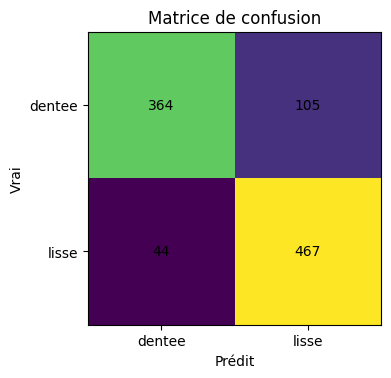

In [5]:
# --- Matrice de confusion
import numpy as np
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Matrice de confusion")
plt.xticks([0,1], train_ds.classes); plt.yticks([0,1], train_ds.classes)
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.xlabel('Prédit'); plt.ylabel('Vrai')
plt.tight_layout()
plt.show()

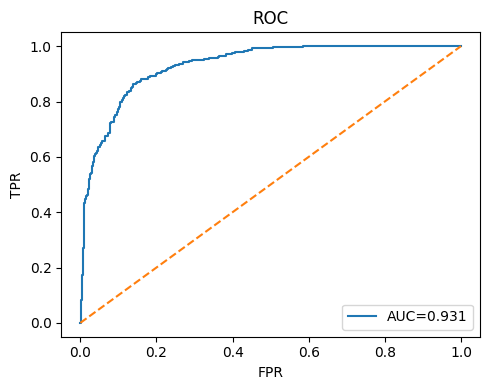

In [6]:
# --- Courbe ROC
fpr, tpr, thr = roc_curve(y_true, y_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, y_prob):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC')
plt.legend(); plt.tight_layout(); plt.show()

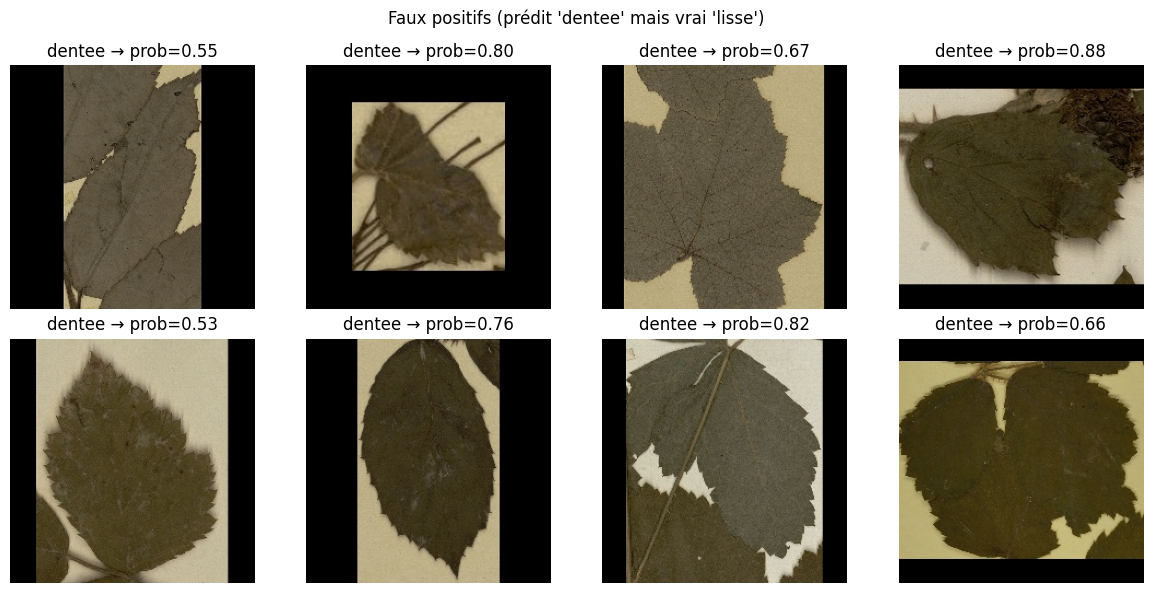

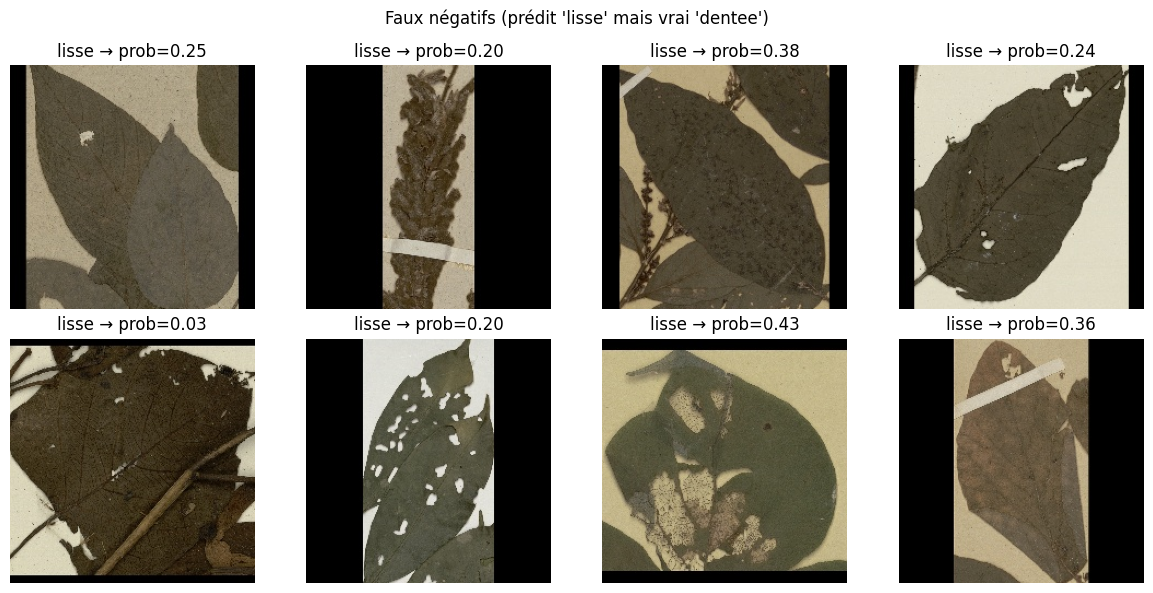

In [7]:
# --- Analyse d'erreurs (quelques FP et FN)
test_paths = [test_ds.samples[i][0] for i in range(len(test_ds))]
fp_idx = [i for i,(yt, yp) in enumerate(zip(y_true, y_pred)) if yt==0 and yp==1]
fn_idx = [i for i,(yt, yp) in enumerate(zip(y_true, y_pred)) if yt==1 and yp==0]

def show_examples(idxs, title, max_n=8):
    n = min(len(idxs), max_n)
    if n == 0:
        print(f"Aucun exemple pour {title}.")
        return
    cols = 4
    rows = math.ceil(n/cols)
    plt.figure(figsize=(cols*3, rows*3))
    for k,i in enumerate(idxs[:n]):
        path = test_paths[i]
        img = plt.imread(path)
        plt.subplot(rows, cols, k+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(Path(path).parent.name + f" → prob={y_prob[i]:.2f}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(fp_idx, "Faux positifs (prédit 'dentee' mais vrai 'lisse')")
show_examples(fn_idx, "Faux négatifs (prédit 'lisse' mais vrai 'dentee')")


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# 1) Data augmentation + normalisation
# =========================================================

# Tu peux utiliser tes propres mean/std si tu les as calculés
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02,
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# IMPORTANT : on applique les nouveaux transforms à tes datasets
# (je suppose que tu as déjà train_ds, val_ds, test_ds)
train_ds.transform = train_tfms
val_ds.transform   = val_test_tfms
test_ds.transform  = val_test_tfms


Device: cuda


In [9]:
# 2) Dataloaders

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)

# Nombre de classes
num_classes = len(train_ds.classes)
print("Classes:", train_ds.classes)


Classes: ['dentee', 'lisse']


In [10]:
# 3) Gestion du déséquilibre des classes (class weights)

if hasattr(train_ds, "targets"):
    labels = train_ds.targets
else:
    # compatibilité ImageFolder
    labels = [s[1] for s in train_ds.samples]

counter = Counter(labels)
print("Nombre d'images par classe:", counter)

counts = torch.tensor([counter[i] for i in range(num_classes)], dtype=torch.float)
class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
print("Class weights:", class_weights)


Nombre d'images par classe: Counter({1: 2381, 0: 2189})
Class weights: tensor([0.5210, 0.4790])


In [11]:
# 4) Modèle ResNet18 + Transfer Learning

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# On gèle tout
for p in model.parameters():
    p.requires_grad = False

# On remplace la tête de classification
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s] 


In [12]:
# 5) Fonctions utilitaires (train / eval)

def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_acc  = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        acc = accuracy_from_logits(logits, y)

        running_loss += loss.item()
        running_acc  += acc
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_acc  = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)
        acc = accuracy_from_logits(logits, y)

        running_loss += loss.item()
        running_acc  += acc
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches

In [13]:
# 6) Phase 1 : entraînement de la tête (fc seulement)

for name, p in model.named_parameters():
    if "fc" in name:
        p.requires_grad = True  # on entraîne seulement la tête

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

EPOCHS_PHASE1 = 15
patience = 5
best_val_acc = 0.0
best_state = None
epochs_without_improve = 0

print("=== Phase 1 : entraînement de la tête ===")
for epoch in range(1, EPOCHS_PHASE1 + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)

    print(f"[Phase1][Epoch {epoch}/{EPOCHS_PHASE1}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping sur la val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= patience:
            print("Early stopping (Phase 1) ")
            break

# On recharge le meilleur modèle de la phase 1
if best_state is not None:
    model.load_state_dict(best_state)

=== Phase 1 : entraînement de la tête ===
[Phase1][Epoch 1/15] Train Loss: 0.6090 | Train Acc: 0.6816 | Val Loss: 0.5207 | Val Acc: 0.7721
[Phase1][Epoch 2/15] Train Loss: 0.4986 | Train Acc: 0.7977 | Val Loss: 0.4412 | Val Acc: 0.8107
[Phase1][Epoch 3/15] Train Loss: 0.4484 | Train Acc: 0.8231 | Val Loss: 0.3871 | Val Acc: 0.8457
[Phase1][Epoch 4/15] Train Loss: 0.4163 | Train Acc: 0.8308 | Val Loss: 0.3862 | Val Acc: 0.8276
[Phase1][Epoch 5/15] Train Loss: 0.3949 | Train Acc: 0.8448 | Val Loss: 0.3503 | Val Acc: 0.8538
[Phase1][Epoch 6/15] Train Loss: 0.3801 | Train Acc: 0.8413 | Val Loss: 0.3279 | Val Acc: 0.8729
[Phase1][Epoch 7/15] Train Loss: 0.3639 | Train Acc: 0.8545 | Val Loss: 0.3384 | Val Acc: 0.8538
[Phase1][Epoch 8/15] Train Loss: 0.3566 | Train Acc: 0.8542 | Val Loss: 0.3204 | Val Acc: 0.8709
[Phase1][Epoch 9/15] Train Loss: 0.3573 | Train Acc: 0.8525 | Val Loss: 0.3042 | Val Acc: 0.8760
[Phase1][Epoch 10/15] Train Loss: 0.3388 | Train Acc: 0.8580 | Val Loss: 0.3036 | Val

In [14]:
# =========================================================
# 7) Phase 2 : Fine-tuning du dernier bloc (layer4 + fc)
# =========================================================

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,          # plus petit learning rate pour le fine-tuning
    weight_decay=1e-4
)

EPOCHS_PHASE2 = 10
patience = 4
epochs_without_improve = 0  # on repart sur une nouvelle patience

print("\n=== Phase 2 : Fine-tuning layer4 + fc ===")
for epoch in range(1, EPOCHS_PHASE2 + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft)
    val_loss, val_acc     = evaluate(model, val_loader, criterion)

    print(f"[Phase2][Epoch {epoch}/{EPOCHS_PHASE2}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= patience:
            print("Early stopping (Phase 2) ")
            break

# On recharge le meilleur état global (phase 1 + 2)
if best_state is not None:
    model.load_state_dict(best_state)

print(f"\n💡 Meilleure accuracy validation obtenue: {best_val_acc:.4f}")


=== Phase 2 : Fine-tuning layer4 + fc ===
[Phase2][Epoch 1/10] Train Loss: 0.2699 | Train Acc: 0.8863 | Val Loss: 0.1510 | Val Acc: 0.9368
[Phase2][Epoch 2/10] Train Loss: 0.1795 | Train Acc: 0.9257 | Val Loss: 0.1256 | Val Acc: 0.9499
[Phase2][Epoch 3/10] Train Loss: 0.1566 | Train Acc: 0.9420 | Val Loss: 0.1155 | Val Acc: 0.9550
[Phase2][Epoch 4/10] Train Loss: 0.1290 | Train Acc: 0.9494 | Val Loss: 0.1213 | Val Acc: 0.9536
[Phase2][Epoch 5/10] Train Loss: 0.1009 | Train Acc: 0.9614 | Val Loss: 0.1185 | Val Acc: 0.9580
[Phase2][Epoch 6/10] Train Loss: 0.0905 | Train Acc: 0.9644 | Val Loss: 0.1196 | Val Acc: 0.9567
[Phase2][Epoch 7/10] Train Loss: 0.0859 | Train Acc: 0.9659 | Val Loss: 0.1195 | Val Acc: 0.9536
[Phase2][Epoch 8/10] Train Loss: 0.0712 | Train Acc: 0.9735 | Val Loss: 0.1059 | Val Acc: 0.9647
[Phase2][Epoch 9/10] Train Loss: 0.0640 | Train Acc: 0.9757 | Val Loss: 0.1203 | Val Acc: 0.9630
[Phase2][Epoch 10/10] Train Loss: 0.0492 | Train Acc: 0.9809 | Val Loss: 0.1067 | Va

In [15]:
# =========================================================
# 8) Évaluation finale sur le test set
# =========================================================

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\n Résultats sur le test set -> Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")


🎯 Résultats sur le test set -> Loss: 0.1360 | Acc: 0.9601


In [16]:
MODEL_PATH = "resnet_leaf_tl.pth"

torch.save({
    "state_dict": model.state_dict(),
    "classes": train_ds.classes,
    "mean": mean,
    "std": std,
}, MODEL_PATH)

print(" Modèle sauvegardé dans", MODEL_PATH)


✅ Modèle sauvegardé dans resnet_leaf_tl.pth
